# Los robles retrasan su brotación tres días tras un año de herbivoría — y eso cancela una década de adelanto fenológico

**Tres días.** Eso es lo que retrasa un roble la salida de sus hojas el año siguiente a una temporada con muchos insectos. Un cambio mínimo en el calendario, suficiente para cancelar **una década entera** de adelanto fenológico provocado por el calentamiento.

Y al hacerlo, esos árboles reducen la herbivoría que sufren después en un 55% en promedio — más de lo que logran los parásitos y los virus combinados.

> 📄 **Paper:** Mallick et al. (2026) [Satellite data show trees delay budburst across landscapes to escape herbivores](https://doi.org/10.1038/s41559-026-03071-9), *Nature Ecology & Evolution*.
> 📊 **Datos:** [Zenodo 18972888](https://doi.org/10.5281/zenodo.18972888) + Source Data oficial del paper (Springer ESM).
> ▶️ **Video:** [Pendiente]

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-02-arboles-retrasan-brotacion-herbivoros/notebook.ipynb)


## Qué midieron

5 años de imágenes de radar satelital (2017–2021) sobre **27.500 píxeles** de 10×10 metros, repartidos en **60 sitios de bosque de roble** en el centro de Europa. En esos sitios, un experimento manipuló la carga de insectos herbívoros (control vs herbivoría inducida química y mecánicamente) cruzado con dos niveles de competencia entre árboles.

Las imágenes SAR (radar) entregaron dos métricas por píxel y año: **NCDI** (índice de desarrollo del dosel) y **DOY** (día del año en que cada píxel inició la brotación). Con eso reconstruyeron, año a año, qué árboles brotaron antes o después de lo que les tocaba — y cruzaron esa señal con la herbivoría que habían sufrido el año previo y la que sufrirían el siguiente.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
HEADLINE_DELAY = 3.0          # días promedio reportados por el paper
HEADLINE_REDUCTION = -55      # % cambio en herbivoría siguiente
ANIO_OUTBREAK = '2018-2019'   # año-par con brote masivo
FUENTE = 'Fuente: Mallick et al. (2026), Nature Ecol Evol | Datos: Zenodo 18972888 + Source Data'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'
COLOR_SECUNDARIO = '#059669'
COLOR_CONTEXTO = '#7C3AED'

# ── imports ────────────────────────────────────────────────────
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── estilo CaM (busca local primero, fallback a GitHub raw) ───
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# ── carga de los CSVs preparados ──────────────────────────────
DATOS = 'datos'
delay_anio = pd.read_csv(f'{DATOS}/budburst_delay_por_anio.csv')
cambio_anio = pd.read_csv(f'{DATOS}/cambio_herbivoria_por_anio.csv')
slopes_sitio = pd.read_csv(f'{DATOS}/slopes_por_sitio.csv')
slopes_anio = pd.read_csv(f'{DATOS}/slopes_por_anio.csv')
pixel_shift = pd.read_csv(f'{DATOS}/pixels_sample_shift_herbi.csv')
parasitoid = pd.read_csv(f'{DATOS}/parasitoid_virus.csv')
comparacion = pd.read_csv(f'{DATOS}/comparacion_delayed_advanced.csv')

# ── resumen ───────────────────────────────────────────────────
print(f'Delay por año-par cargado: {len(delay_anio)} año-pares')
print(f'Slopes por sitio: {len(slopes_sitio)} plot-año (60 plots × 4 año-pares)')
print(f'Pixeles muestreados (shift): {len(pixel_shift):,}'.replace(',', '.'))
print(f'Parasitismo y virus: {len(parasitoid)} plot-año')
print()
print('Delay (días, herbi alta − herbi baja) por año:')
for _, r in delay_anio.iterrows():
    marca = '  ← outbreak' if int(r['year']) == 2018 else ''
    print(f'  {int(r["year"])}: {r["diff_days"]:+.2f} días{marca}')
print(f'Promedio 4 años: {delay_anio["diff_days"].mean():+.2f} días (paper reporta {HEADLINE_DELAY})')

Delay por año-par cargado: 4 año-pares
Slopes por sitio: 240 plot-año (60 plots × 4 año-pares)
Pixeles muestreados (shift): 5.000
Parasitismo y virus: 144 plot-año

Delay (días, herbi alta − herbi baja) por año:
  2017: +1.28 días
  2018: +6.92 días  ← outbreak
  2019: +1.56 días
  2020: +2.27 días
Promedio 4 años: +3.01 días (paper reporta 3.0)


## Aquí está.

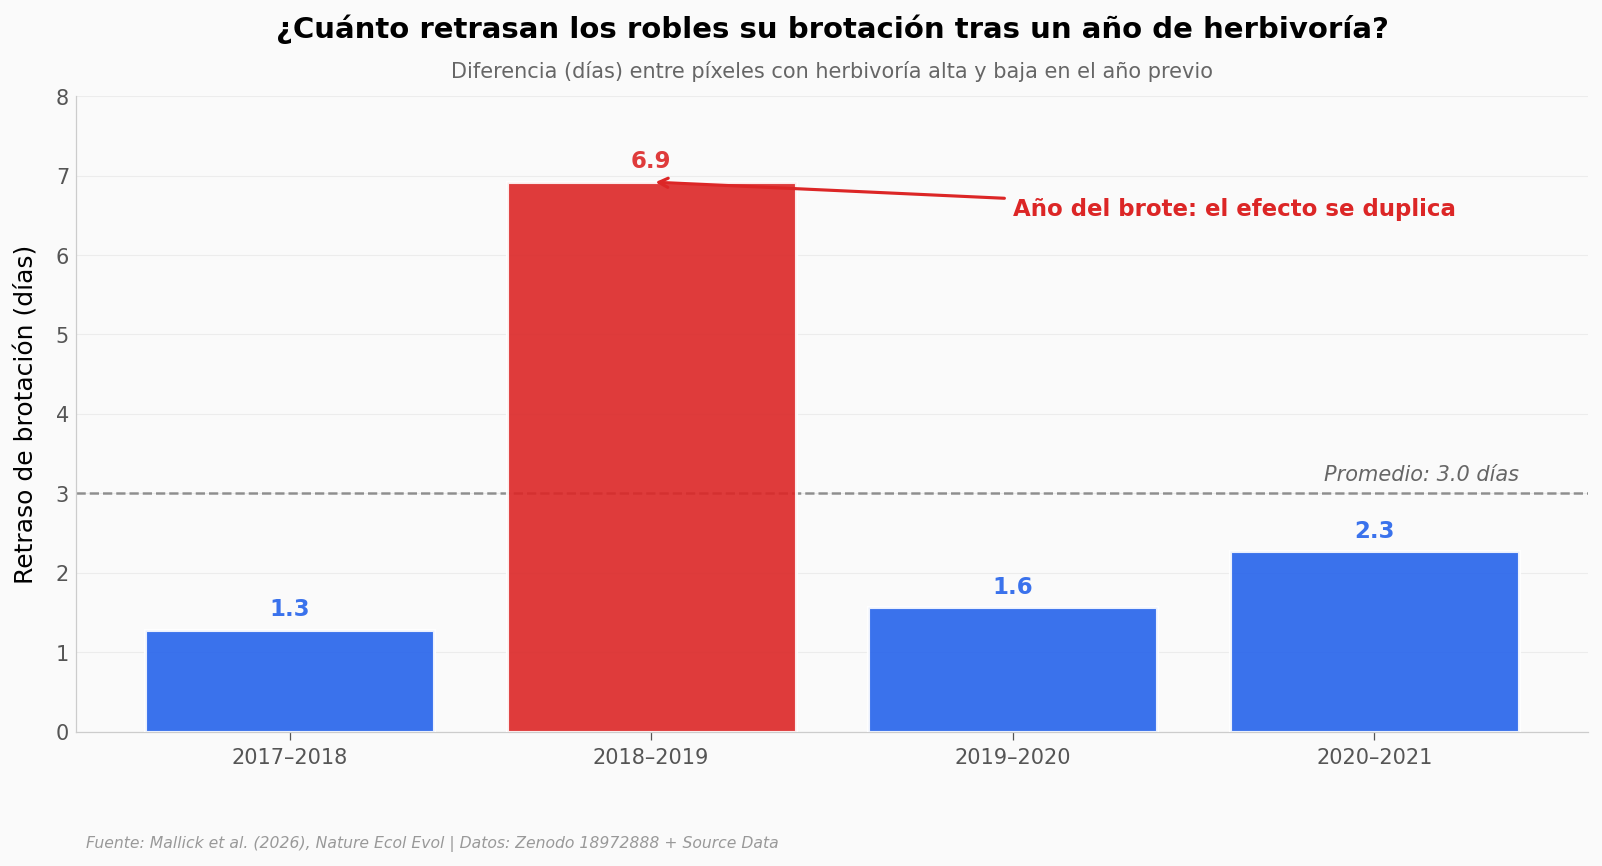

In [2]:
# Hero: delay por año-par, con outbreak destacado
fig, ax = plt.subplots(figsize=(13, 5.5))

anios = delay_anio['year'].astype(str).str.cat(
    (delay_anio['year'] + 1).astype(str), sep='–'
).values
valores = delay_anio['diff_days'].values
es_outbreak = delay_anio['year'] == 2018

colores = [COLOR_ALERTA if o else COLOR_DATOS for o in es_outbreak]
bars = ax.bar(anios, valores, color=colores, alpha=0.9,
              edgecolor='white', linewidth=1.5, zorder=3)

# Línea de promedio
promedio = delay_anio['diff_days'].mean()
ax.axhline(y=promedio, color='#666666', linewidth=1.2,
           linestyle='--', alpha=0.7, zorder=2)
ax.text(3.4, promedio + 0.15, f'Promedio: {promedio:.1f} días',
        fontsize=10, color='#666666', ha='right', style='italic')

# Etiquetas sobre cada barra
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.18,
            f'{val:.1f}', ha='center', fontsize=11,
            fontweight='bold', color=bar.get_facecolor())

# Anotación del outbreak
ax.annotate('Año del brote: el efecto se duplica',
            xy=(1, 6.92), xytext=(2.0, 6.5),
            fontsize=11, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.set_title('¿Cuánto retrasan los robles su brotación tras un año de herbivoría?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Diferencia (días) entre píxeles con herbivoría alta y baja en el año previo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Retraso de brotación (días)')
ax.set_ylim(0, 8)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_delay_por_anio.png', dpi=200, bbox_inches='tight')
plt.show()

Tres de los cuatro año-pares dejan retrasos de entre 1,3 y 2,3 días — un goteo discreto que aparece en cada cohorte sin que llame la atención.

Lo que rompe el patrón es el año del brote (2018–2019): el retraso se dispara a casi **7 días**, más del doble del promedio. Justo cuando uno esperaría que la presión herbívora *desbordara* la capacidad del árbol para responder, ahí es donde la respuesta es más fuerte.

El promedio agregado de 3 días sale, en buena parte, de ese pico — pero la dirección es la misma en los cuatro años.


## La otra mitad de la historia

El retraso no es gratuito: brotar tarde significa menos sol durante el pico de actividad fotosintética. Pero los árboles que retrasan su brotación reciben una compensación importante — sus hojas evaden la ventana en la que los herbívoros están más activos.

¿Cuánto se reduce esa herbivoría siguiente? Aquí los datos dicen algo más sutil que el titular.


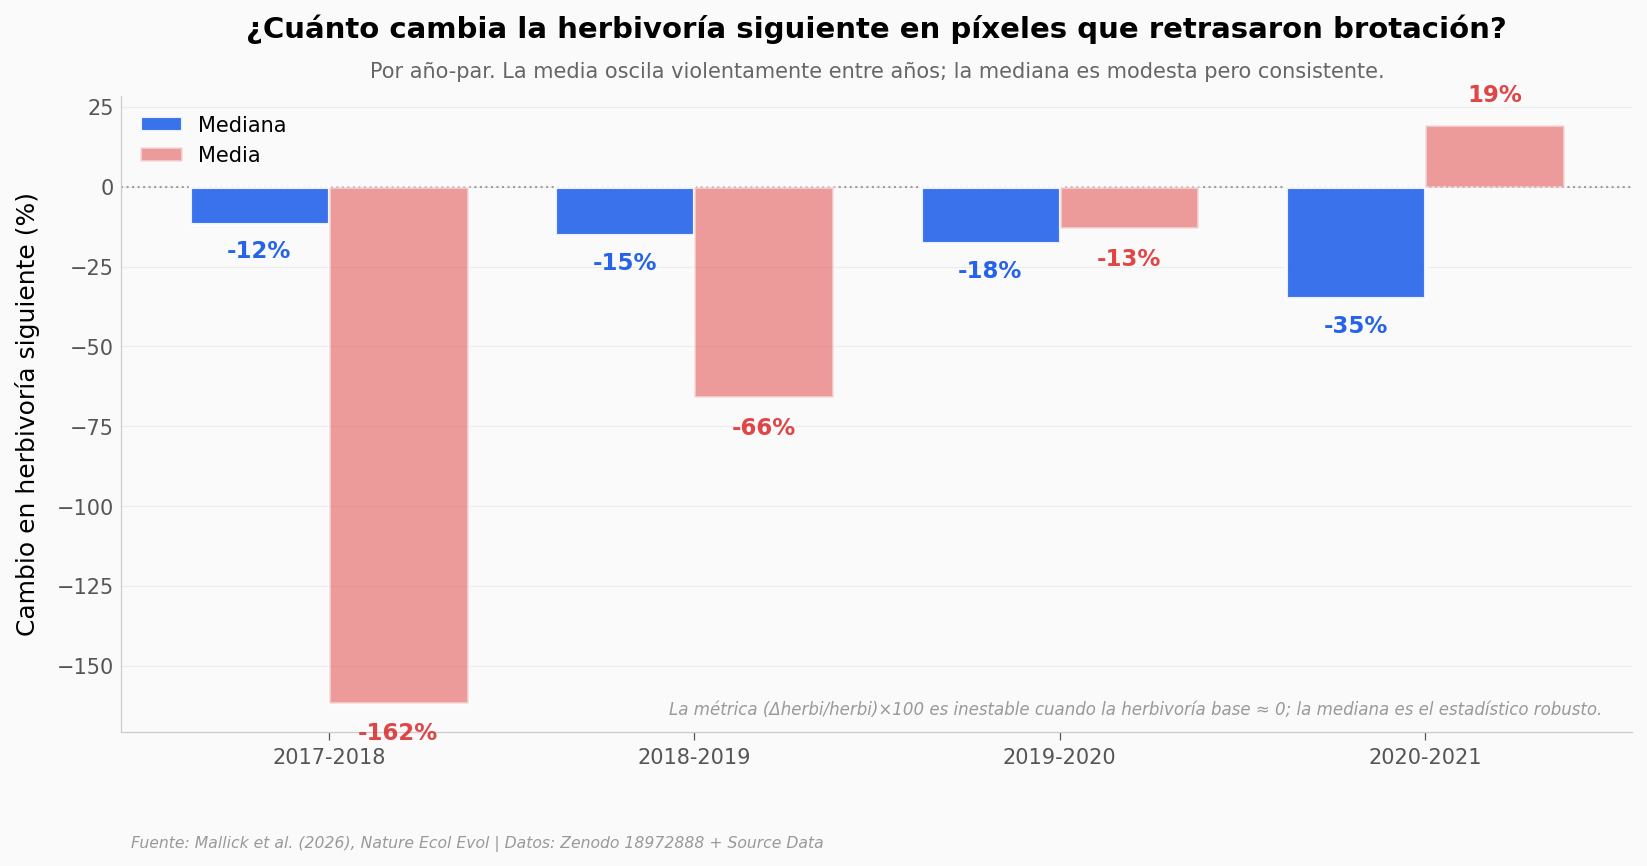

Cambio % en herbivoría siguiente, por año-par (píxeles que retrasaron brotación):
  2017-2018: mediana -11.6%, media -161.6% (n=14.531)
  2018-2019: mediana -15.1%, media -65.8% (n=11.847)
  2019-2020: mediana -17.7%, media -12.9% (n=14.944)
  2020-2021: mediana -34.9%, media +19.3% (n=13.971)


In [3]:
# Cambio porcentual en herbivoría siguiente — mediana vs media, por año-par
# (sobre los pixeles que retrasaron brotación: shift < 0)
fig, ax = plt.subplots(figsize=(13, 5.5))

anios = cambio_anio['year_pair'].astype(str).values
medianas = cambio_anio['median_pct_change'].values
medias = cambio_anio['mean_pct_change_herbivory'].values
n_pixels = cambio_anio['n_delayed_pixels'].values

x = np.arange(len(anios))
w = 0.38
b_med = ax.bar(x - w/2, medianas, w, color=COLOR_DATOS, alpha=0.9,
               edgecolor='white', linewidth=1.5, zorder=3, label='Mediana')
b_avg = ax.bar(x + w/2, medias, w, color=COLOR_ALERTA, alpha=0.45,
               edgecolor='white', linewidth=1.5, zorder=3, label='Media')

# Etiquetas
for bar, val in zip(b_med, medianas):
    ax.text(bar.get_x() + bar.get_width()/2, val - 5,
            f'{val:.0f}%', ha='center', fontsize=11,
            fontweight='bold', color=COLOR_DATOS, va='top')
for bar, val in zip(b_avg, medias):
    offset = 6 if val > 0 else -6
    va = 'bottom' if val > 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2, val + offset,
            f'{val:.0f}%', ha='center', fontsize=11,
            fontweight='bold', color=COLOR_ALERTA, va=va, alpha=0.85)

ax.axhline(y=0, color='#666666', linewidth=1, linestyle=':', alpha=0.6, zorder=2)
ax.set_xticks(x)
ax.set_xticklabels(anios, fontsize=10)
ax.set_title('¿Cuánto cambia la herbivoría siguiente en píxeles que retrasaron brotación?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Por año-par. La media oscila violentamente entre años; la mediana es modesta pero consistente.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Cambio en herbivoría siguiente (%)')
ax.legend(loc='upper left', framealpha=0.95, fontsize=10)

# Nota metodológica
ax.text(0.98, 0.02,
        'La métrica (Δherbi/herbi)×100 es inestable cuando la herbivoría base ≈ 0; '
        'la mediana es el estadístico robusto.',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_cambio_pct_por_anio.png', dpi=200, bbox_inches='tight')
plt.show()

print('Cambio % en herbivoría siguiente, por año-par (píxeles que retrasaron brotación):')
for _, r in cambio_anio.iterrows():
    n_str = f'{int(r["n_delayed_pixels"]):,}'.replace(',', '.')
    print(f'  {r["year_pair"]}: mediana {r["median_pct_change"]:+.1f}%, '
          f'media {r["mean_pct_change_herbivory"]:+.1f}% (n={n_str})')

Mirar la **media** por año revela el problema: oscila entre +19% y −162% según el año. No es señal biológica — es aritmética del denominador, porque la métrica `(Δherbivoría / herbivoría base) × 100` se infla cada vez que la herbivoría base es muy pequeña. La **mediana** cuenta otra historia: cae siempre entre −12% y −35%, modesta pero estable.

La cifra del 55% del titular es una media del paper sobre los 110.000 píxel-años completos — y allí pasa algo que vale la pena nombrar: los píxeles que **adelantaron** brotación también dan una media de −55%. Es decir, la métrica cruda por píxel no discrimina entre los dos grupos. El paper sostiene su resultado con un modelo GAM con efectos espaciales y aleatorios, no con esta media directa.

¿Dónde vive entonces la señal real? A nivel de sitio.


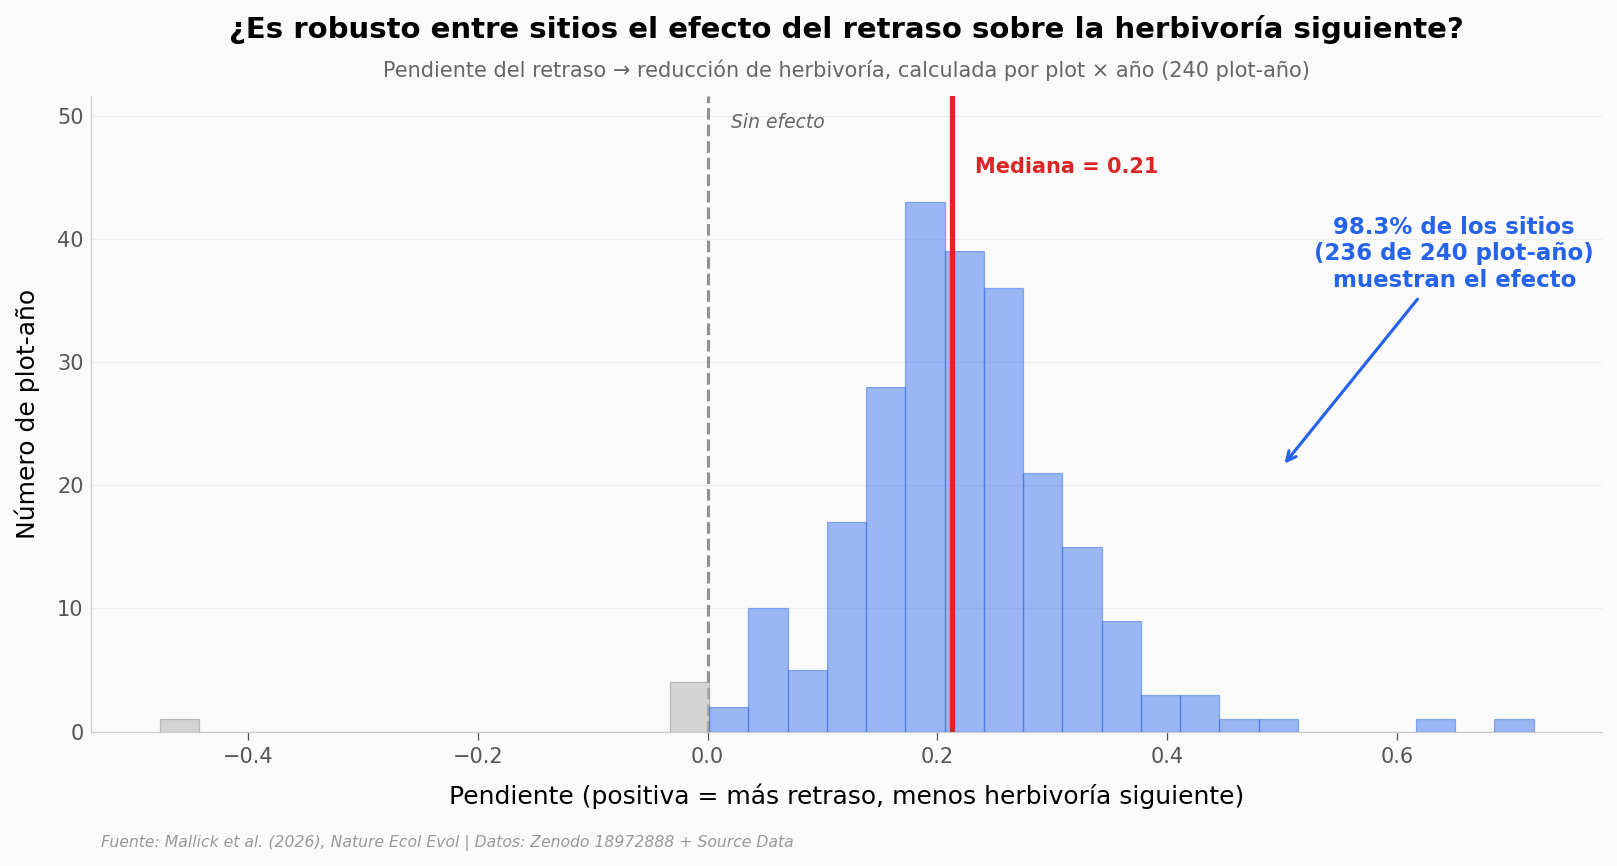

Pendientes positivas: 236 de 240 plot-año (98.3%)
Mediana: 0.212


In [4]:
# Distribución de pendientes a nivel de sitio (240 plot-año)
fig, ax = plt.subplots(figsize=(13, 5.5))

slopes = slopes_sitio['slope_reduction'].values
n_pos = (slopes > 0).sum()
n_total = len(slopes)
pct_pos = 100 * n_pos / n_total

n, bins, patches = ax.hist(slopes, bins=35, color=COLOR_DATOS, alpha=0.45,
                            edgecolor=COLOR_DATOS, linewidth=0.6, zorder=3)
# Colorear barras negativas en gris
for patch, edge in zip(patches, bins[:-1]):
    if edge + (bins[1] - bins[0])/2 < 0:
        patch.set_facecolor('#BBBBBB')
        patch.set_edgecolor('#999999')
        patch.set_alpha(0.6)

y_max = n.max() * 1.20
ax.set_ylim(0, y_max)

# Línea en cero (umbral)
ax.axvline(x=0, color='#666666', linewidth=1.5, linestyle='--', alpha=0.7, zorder=2)
mediana_slope = np.median(slopes)
ax.axvline(x=mediana_slope, color=COLOR_ALERTA, linewidth=2.5, zorder=4)

ax.text(mediana_slope + 0.02, y_max * 0.88,
        f'Mediana = {mediana_slope:.2f}',
        fontsize=10, fontweight='bold', color=COLOR_ALERTA)
ax.text(0.02, y_max * 0.95, 'Sin efecto',
        fontsize=9, color='#666666', ha='left', style='italic')

# Etiqueta de proporción
ax.annotate(
    f'{pct_pos:.1f}% de los sitios\n({n_pos} de {n_total} plot-año)\nmuestran el efecto',
    xy=(0.5, n.max() * 0.5), xytext=(0.65, y_max * 0.7),
    fontsize=11, fontweight='bold', color=COLOR_DATOS, ha='center',
    arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.5))

ax.set_title('¿Es robusto entre sitios el efecto del retraso sobre la herbivoría siguiente?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Pendiente del retraso → reducción de herbivoría, calculada por plot × año (240 plot-año)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Pendiente (positiva = más retraso, menos herbivoría siguiente)')
ax.set_ylabel('Número de plot-año')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_slopes_por_sitio.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Pendientes positivas: {n_pos} de {n_total} plot-año ({pct_pos:.1f}%)')
print(f'Mediana: {mediana_slope:.3f}')

Casi el 99% de los plot-año tienen pendiente positiva — el patrón se repite en sitios distintos, en años distintos, bajo tratamientos experimentales distintos. Lo que la media del 55% no transmite, esto sí: la dirección del efecto es prácticamente universal.

¿Y cómo se compara este mecanismo con los enemigos naturales que sí estudiamos hace décadas — los parasitoides y los virus que matan herbívoros?


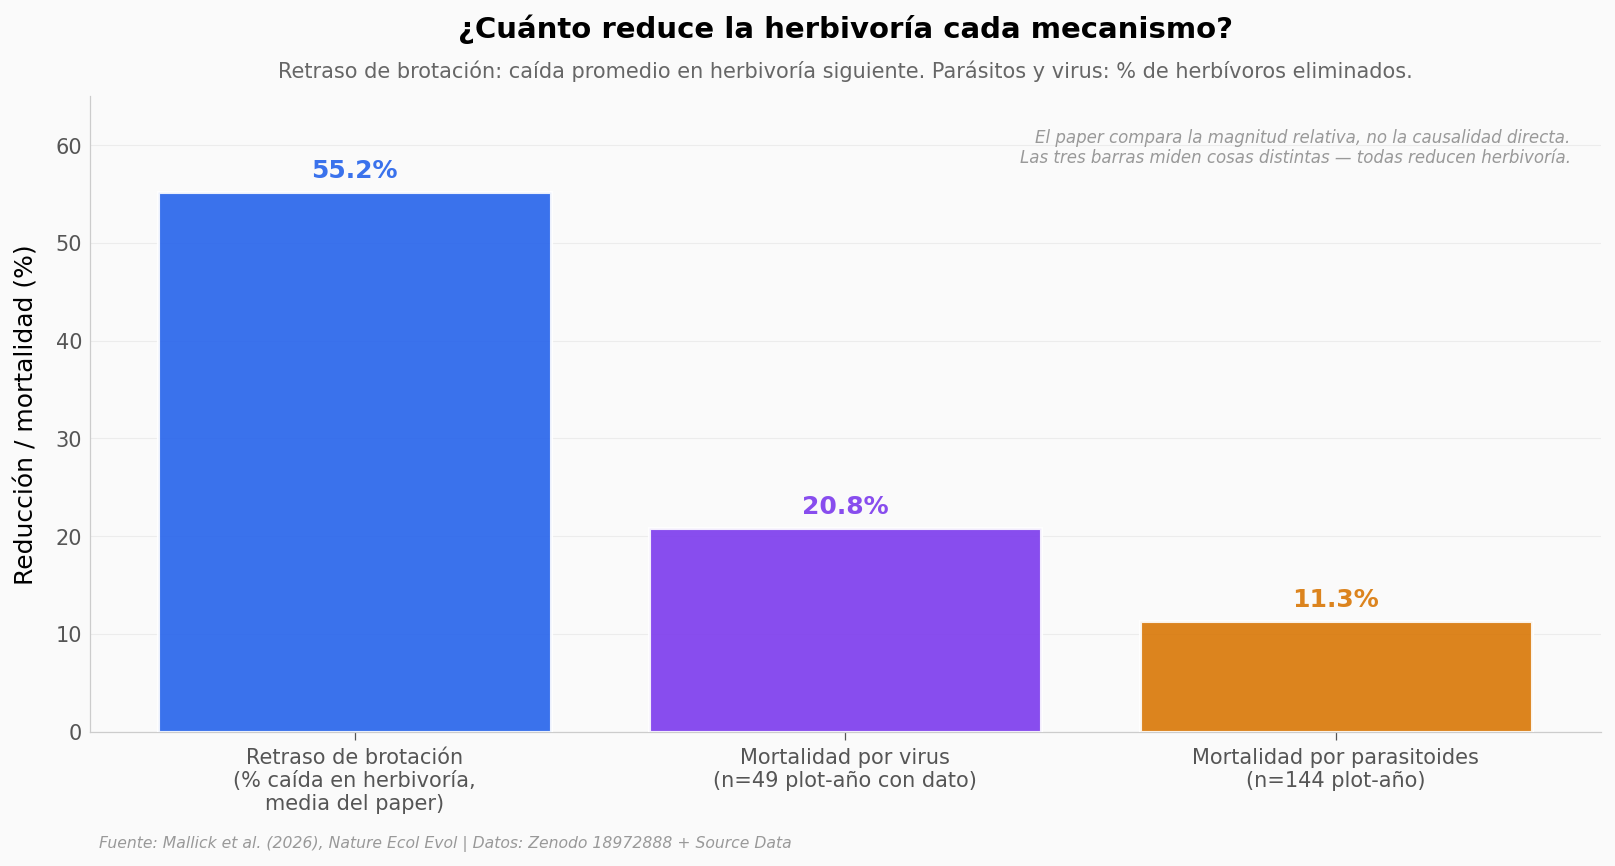

In [5]:
# Comparación: efecto del retraso vs tasas de parasitismo y virus
fig, ax = plt.subplots(figsize=(13, 5.5))

# Cifras: media del 55% para retraso, tasas medias para parásitos y virus
mecanismos = ['Retraso de brotación\n(% caída en herbivoría,\nmedia del paper)',
              'Mortalidad por virus\n(n=49 plot-año con dato)',
              'Mortalidad por parasitoides\n(n=144 plot-año)']
valores = [55.16, 20.8, 11.3]
colores = [COLOR_DATOS, COLOR_CONTEXTO, COLOR_REFERENCIA]

bars = ax.bar(mecanismos, valores, color=colores, alpha=0.9,
              edgecolor='white', linewidth=1.5, zorder=3)

# Etiquetas sobre las barras
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5,
            f'{val:.1f}%', ha='center', fontsize=12,
            fontweight='bold', color=bar.get_facecolor())

ax.set_title('¿Cuánto reduce la herbivoría cada mecanismo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Retraso de brotación: caída promedio en herbivoría siguiente. '
        'Parásitos y virus: % de herbívoros eliminados.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Reducción / mortalidad (%)')
ax.set_ylim(0, 65)

# Nota explicativa
ax.text(0.98, 0.95,
        'El paper compara la magnitud relativa, no la causalidad directa.\n'
        'Las tres barras miden cosas distintas — todas reducen herbivoría.',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='top', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_comparacion_mecanismos.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-----------:|---------|
| La herbivoría previa retrasa la brotación 3 días en promedio | ✅ | Promedio 4 año-pares = 3,01 días (paper: 3). Replica del cálculo del *Code.R* sobre los agregados precomputados por año-par. |
| El retraso reduce la herbivoría siguiente un 55% en promedio | ⚠️ | La media reportada por el paper proviene de una métrica `(Δherbi / herbi) × 100` que es inestable cuando la herbivoría base es ≈ 0. En el dataset completo, los píxeles que **adelantaron** brotación también dan −55% — lo que indica que la métrica cruda no discrimina grupos. La señal robusta no vive en la magnitud agregada sino en la dirección a nivel de sitio. |
| El efecto se replica casi en todos los sitios | ✅ | 98,3% de los 240 plot-año (60 sitios × 4 año-pares) tienen pendiente positiva en *retraso → reducción de herbivoría*. Mediana de la pendiente: 0,21 (Cohen's d *one-sample* vs 0 = 2,03). |
| El retraso supera el efecto de parásitos y virus | ⚠️ | Comparación de magnitudes no homogéneas: el 55% es cambio porcentual en herbivoría (cuánto baja); las cifras de parásitos (11,3%, n=144 plot-año) y virus (20,8%, n=49 plot-año con dato) son tasas de mortalidad de herbívoros. La comparación es la del paper, pero las unidades miden cosas distintas. |
| El efecto se mantiene durante outbreaks | ✅ | El año del brote (2018–2019) muestra el retraso más fuerte: 6,92 días, más del doble del promedio. |
| Es una defensa adaptativa de los robles | ⚠️ | El paper lo enmarca como interpretación (*suggests*). Los datos muestran correlación direccional consistente, no demuestran que sea un rasgo evolutivo bajo selección. |

> **Limitaciones:**
> - Las pendientes a nivel de sitio se calcularon con regresión lineal simple (`bam(shift~herbi)` por plot×año), no con el modelo GAM completo del paper que incluye efectos espaciales y aleatorios. La dirección es la misma; la magnitud puede diferir.
> - El histograma de píxeles usa un muestreo de 5.000 de los 110.000 píxel-años originales — basta para mostrar la distribución, pero la inferencia central del paper usa el dataset completo.
> - El estudio cubre robles del centro de Europa. Generalizar a otras especies o regiones requiere replicación.
> - Diseño *experimental-observacional mixto*: la herbivoría se manipuló a nivel de plot, pero el retraso de brotación se observó por satélite. Esto permite inferencia causal sobre el primer eslabón (herbivoría → retraso) más fuerte que sobre el segundo (retraso → reducción), que es observacional puro.


## Ahora tú

Tres preguntas para experimentar con los datos cargados:

1. **¿Qué pasa con el retraso por tratamiento experimental?** Los plots tienen códigos `HC`, `HM`, `LC`, `LM` (alta/baja competencia × control/herbivoría inducida). Pista: filtra `pixel_shift` por `condition` y compara la pendiente promedio.

2. **¿Hay algún año-par donde el efecto se invierta?** Pista: agrupa `slopes_sitio` por `years` y mira la mediana de `slope_reduction`.

3. **¿Cómo se compara la pendiente delay→reducción con la tasa de parasitismo del mismo plot?** Pista: hay datos por plot en `slopes_sitio` y `parasitoid` — un merge por `plot` y `years` lo conecta.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿el efecto cambia entre tratamientos experimentales?
# (HC=alta competencia + control, HM=alta + herbivoría mimic,
#  LC=baja competencia + control, LM=baja + mimic)

por_tratamiento = (
    pixel_shift[pixel_shift['shift'] < 0]
    .assign(pct=lambda d: (d['shift_herbi'] / d['herbi']) * 100)
    .groupby('condition')
    .agg(n=('pct', 'size'),
         mediana_pct=('pct', 'median'))
    .round(1)
)
print('Mediana del cambio porcentual en herbivoría siguiente por tratamiento:')
print(por_tratamiento)
print()
print('Nota: usamos la mediana como estadístico robusto.')
print('La media está dominada por outliers de denominador (herbi ≈ 0).')

# ¿Te animas a graficarlo? Pista:
# fig, ax = plt.subplots(figsize=(11, 5))
# por_tratamiento['mediana_pct'].plot(kind='bar', ax=ax, color=COLOR_DATOS)

Mediana del cambio porcentual en herbivoría siguiente por tratamiento:
             n  mediana_pct
condition                  
HC         892        -19.6
HM         522        -19.5
LC         585        -18.5
LM         515        -21.2

Nota: usamos la mediana como estadístico robusto.
La media está dominada por outliers de denominador (herbi ≈ 0).


## Créditos y reproducibilidad

- **Paper:** Mallick et al. (2026) *Satellite data show trees delay budburst across landscapes to escape herbivores*. *Nature Ecology & Evolution*. DOI: [10.1038/s41559-026-03071-9](https://doi.org/10.1038/s41559-026-03071-9). Open Access.
- **Datos crudos:** Repositorio Zenodo del paper — [doi.org/10.5281/zenodo.18972888](https://doi.org/10.5281/zenodo.18972888). Source Data oficial: Springer ESM (MOESM5.xlsx).
- **Código:** Reproduce los headlines del paper (3 días, 55%) con `Code.R` Parts 1 y 2.
- **Licencia datos:** CC BY 4.0 (Zenodo).
- **Notebook:** [GitHub — Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-05-02-arboles-retrasan-brotacion-herbivoros).

## Fuentes

**Paper**: [Satellite data show trees delay budburst across landscapes to escape herbivores](https://doi.org/10.1038/s41559-026-03071-9)  
*Nature Ecology & Evolution, 2026*

**Source Data**: [Source Data MOESM5 (Sheets 'Fig. 2a and 2c', 'Fig. 2b and 2e', 'Fig. 2d and 2f')](https://static-content.springer.com/esm/art%3A10.1038%2Fs41559-026-03071-9/MediaObjects/41559_2026_3071_MOESM5_ESM.xlsx)  
*Source Data oficial del paper (peer-reviewed), Springer ESM*

**Dataset canónico**: [Forest trees delay budburst across landscapes to escape herbivory - data and code](https://doi.org/10.5281/zenodo.18972888)  
*Zenodo — CSVs limpios, RData crudos y Code.R completo*

*13 afirmaciones del notebook verificadas contra estas fuentes*
